<a href="https://colab.research.google.com/github/i-ninte/ATS/blob/main/damage_detection_and_ocr_models_license_and_docs(with_tables).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Load the model and image processor
processor = AutoImageProcessor.from_pretrained("beingamit99/car_damage_detection")
model = AutoModelForImageClassification.from_pretrained("beingamit99/car_damage_detection")

# Load and process the image (replace with your image path)
image_path = "download1.jpeg"
image = Image.open(image_path)

# Preprocess the image
inputs = processor(images=image, return_tensors="pt")

# Make predictions
outputs = model(**inputs)

# Get the logits (raw model outputs)
logits = outputs.logits.detach().cpu().numpy()

# Get the predicted class ID and probability
predicted_class_id = np.argmax(logits)
predicted_proba = np.max(logits)

# Map the class ID to the corresponding label
label_map = model.config.id2label
predicted_class_name = label_map[predicted_class_id]

# Print the results
print(f"Predicted class: {predicted_class_name} (probability: {predicted_proba:.4f})")


Predicted class: Dent (probability: 4.0283)


100%|██████████| 90.8M/90.8M [00:03<00:00, 27.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nickyazdani/license-plate-text-recognition-dataset/versions/1
Found 20000 images.


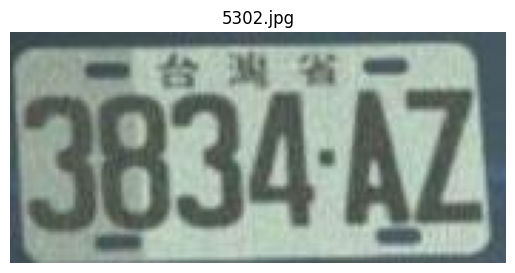

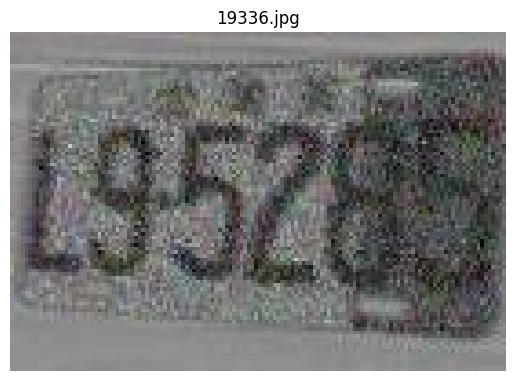

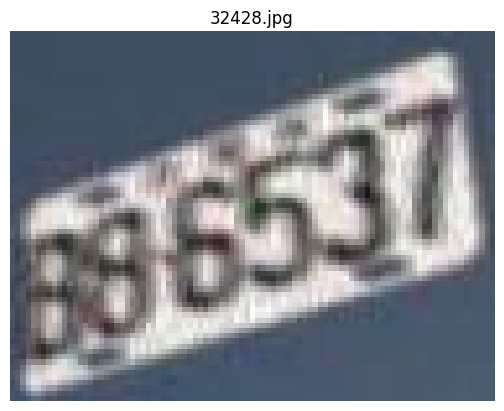

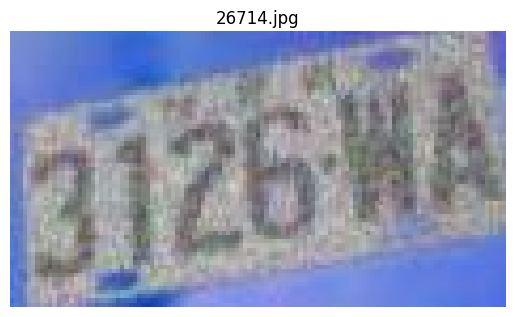

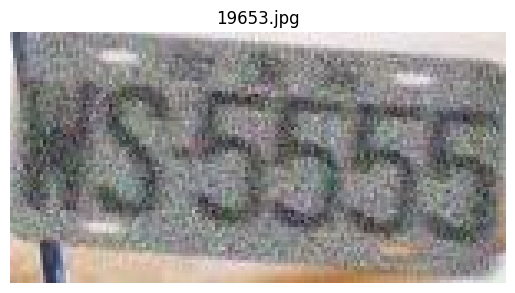

In [ ]:
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt

# Download the latest version of the dataset
path = kagglehub.dataset_download("nickyazdani/license-plate-text-recognition-dataset")
print("Path to dataset files:", path)

# Recursively search for image files in the dataset folder
image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):  # Adjust for your image formats
            image_files.append(os.path.join(root, file))

# Check if we found any images
if not image_files:
    print("No images found in the dataset folder.")
else:
    print(f"Found {len(image_files)} images.")

    # Display the first 5 images
    for img_path in image_files[:5]:
        img = Image.open(img_path)
        plt.figure()
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.basename(img_path))

    plt.show()


# OCR model for vehicle number plate detection

model one

In [ ]:
!pip install transformers

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-to-text", model="DunnBC22/trocr-base-printed_license_plates_ocr")

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

KeyError: <class 'transformers.models.vision_encoder_decoder.configuration_vision_encoder_decoder.VisionEncoderDecoderConfig'>

In [ ]:
from transformers import VisionEncoderDecoderModel, AutoTokenizer
from transformers import ViTFeatureExtractor
from PIL import Image
import torch

# Load model and tokenizer
model = VisionEncoderDecoderModel.from_pretrained("DunnBC22/trocr-base-printed_license_plates_ocr")
tokenizer = AutoTokenizer.from_pretrained("DunnBC22/trocr-base-printed_license_plates_ocr")
feature_extractor = ViTFeatureExtractor.from_pretrained("DunnBC22/trocr-base-printed_license_plates_ocr")

# Load an image
image = Image.open("/content/-5785384170086842267_121_jpg.rf.36ddb132be75483cdf5b3f93fd8eb364.jpg")

# Preprocess the image
pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values

# Generate text from the image
output_ids = model.generate(pixel_values)
generated_text = tokenizer.batch_decode(output_ids, skip_special_tokens=True)

print("Generated text:", generated_text)


KeyError: <class 'transformers.models.vision_encoder_decoder.configuration_vision_encoder_decoder.VisionEncoderDecoderConfig'>

In [ ]:
from transformers import VisionEncoderDecoderModel, AutoTokenizer, ViTFeatureExtractor
from PIL import Image

# Load model and tokenizer
model = VisionEncoderDecoderModel.from_pretrained("DunnBC22/trocr-base-printed_license_plates_ocr")
tokenizer = AutoTokenizer.from_pretrained("DunnBC22/trocr-base-printed_license_plates_ocr")
feature_extractor = ViTFeatureExtractor.from_pretrained("DunnBC22/trocr-base-printed_license_plates_ocr")

# Load an image
image = Image.open("/content/-5785384170086842267_121_jpg.rf.36ddb132be75483cdf5b3f93fd8eb364.jpg")

# Preprocess the image
pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values

# Generate text from the image
output_ids = model.generate(pixel_values)
generated_text = tokenizer.batch_decode(output_ids, skip_special_tokens=True)

print("Generated text:", generated_text)


KeyError: <class 'transformers.models.vision_encoder_decoder.configuration_vision_encoder_decoder.VisionEncoderDecoderConfig'>

In [ ]:
from transformers import pipeline

# Use the object-detection pipeline with the correct model
pipe = pipeline("object-detection", model="nickmuchi/yolos-small-finetuned-license-plate-detection")

# Load an image to test (replace with the path to your image)
image_path = "p/content/-5785384170086842267_121_jpg.rf.36ddb132be75483cdf5b3f93fd8eb364.jpg"

# Perform object detection
results = pipe(image_path)

# Display the detection results
for result in results:
    print(result)


config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/123M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


ValueError: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to an image file, or a base64 encoded string. Got p/content/-5785384170086842267_121_jpg.rf.36ddb132be75483cdf5b3f93fd8eb364.jpg. Failed with cannot identify image file <_io.BytesIO object at 0x7cb90ac1f4c0>

In [ ]:
from transformers import pipeline

pipe = pipeline("object-detection", model="nickmuchi/yolos-small-finetuned-license-plate-detection")

# Test with a known image
test_image = "https://www.google.com/imgres?q=ghana%20number%20plates%20image&imgurl=https%3A%2F%2Flicenseplatemania.com%2Ffotos%2Fghana%2Fghana1.jpg&imgrefurl=https%3A%2F%2Flicenseplatemania.com%2Flandenpaginas%2Fghana.htm&docid=cW_MFToVMHq2FM&tbnid=f-tLjBjubyRCrM&vet=12ahUKEwjCu933np-JAxUiZ0EAHcrhG2cQM3oECDUQAA..i&w=600&h=330&hcb=2&ved=2ahUKEwjCu933np-JAxUiZ0EAHcrhG2cQM3oECDUQAA"
results = pipe(test_image)

for result in results:
    print(result)


UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7cb9086d3290>

In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image
import requests

url = 'https://drive.google.com/uc?id=1p9wJIqRz3W50e2f_A0D8ftla8hoXz4T5'
image = Image.open(requests.get(url, stream=True).raw)
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
inputs = feature_extractor(images=image, return_tensors="pt")
outputs = model(**inputs)

# model predicts bounding boxes and corresponding face mask detection classes
logits = outputs.logits
bboxes = outputs.pred_boxes


/usr/local/lib/python3.10/dist-packages/transformers/models/yolos/feature_extraction_yolos.py:38: FutureWarning: The class YolosFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use YolosImageProcessor instead.
  warnings.warn(


In [ ]:
bboxes

tensor([[[0.3033, 0.5448, 0.0424, 0.0167],
         [0.8891, 0.7774, 0.0742, 0.0902],
         [0.7768, 0.7274, 0.1546, 0.0728],
         [0.7789, 0.7281, 0.1519, 0.0692],
         [0.8879, 0.7119, 0.0640, 0.0531],
         [0.1540, 0.5249, 0.0395, 0.0144],
         [0.6821, 0.5387, 0.2857, 0.0933],
         [0.7763, 0.7266, 0.1550, 0.0734],
         [0.7538, 0.7644, 0.2929, 0.1170],
         [0.6585, 0.6172, 0.2517, 0.1383],
         [0.8019, 0.5649, 0.0859, 0.0339],
         [0.7956, 0.7214, 0.1534, 0.0668],
         [0.8835, 0.7015, 0.0606, 0.0580],
         [0.7183, 0.7524, 0.3722, 0.1340],
         [0.8773, 0.7067, 0.0510, 0.0527],
         [0.3413, 0.5128, 0.0223, 0.0161],
         [0.8795, 0.6698, 0.0604, 0.0866],
         [0.3021, 0.5450, 0.0427, 0.0157],
         [0.8797, 0.7825, 0.0903, 0.0905],
         [0.4716, 0.6384, 0.0866, 0.1729],
         [0.7797, 0.7250, 0.1431, 0.0666],
         [0.3038, 0.5440, 0.0393, 0.0186],
         [0.3011, 0.5474, 0.0411, 0.0165],
         [0

In [ ]:
logits

tensor([[[ -7.5264,  -1.4421,   6.0180],
         [ -9.0119,  -4.4231,  10.3784],
         [ -5.3102,  -2.2659,   6.2314],
         [ -5.0491,  -2.3750,   6.1031],
         [ -8.1141,  -3.0370,   8.5126],
         [ -7.8788,  -3.3876,   8.4335],
         [ -8.3470,  -4.3335,   9.5573],
         [ -5.5968,  -2.1758,   6.3239],
         [ -9.8789,  -4.6652,  10.8463],
         [ -8.5351,  -4.1094,   9.8469],
         [ -8.1701,  -3.6825,   9.5555],
         [ -6.5887,  -2.8567,   7.5636],
         [ -8.6300,  -2.7303,   8.3237],
         [ -9.0447,  -3.9037,  10.0488],
         [ -8.2703,  -2.3912,   7.7450],
         [ -8.1010,   1.3336,   3.7886],
         [ -8.6729,  -4.3183,  10.3192],
         [ -7.7345,  -0.8339,   5.4247],
         [ -9.2277,  -4.2333,  10.1236],
         [ -9.6685,  -4.9698,  11.6422],
         [ -5.3707,  -2.0991,   6.0930],
         [ -7.6571,  -1.2098,   5.7158],
         [ -7.6797,  -0.7380,   5.1496],
         [ -8.1773,  -3.1037,   8.6868],
         [ -6.48

# license plate detection

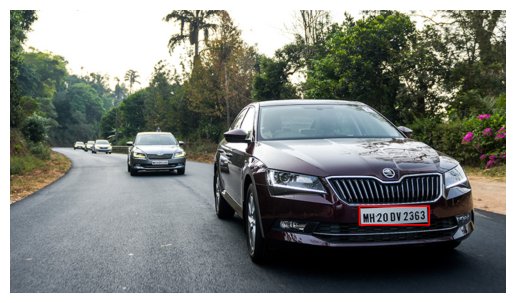

In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image, ImageDraw
import requests
import torch
import matplotlib.pyplot as plt

# Load the image from a URL
url = 'https://drive.google.com/uc?id=1p9wJIqRz3W50e2f_A0D8ftla8hoXz4T5'
image = Image.open(requests.get(url, stream=True).raw)

# Initialize feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities (softmax) and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the last class (background)
scores, labels = probs.max(-1)

# Filter predictions with a confidence threshold
threshold = 0.5
predicted_boxes = bboxes[scores > threshold].detach().cpu().numpy()

# Draw the bounding boxes on the image
draw = ImageDraw.Draw(image)

for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = (x_center - width / 2) * image.width
    x_max = (x_center + width / 2) * image.width
    y_min = (y_center - height / 2) * image.height
    y_max = (y_center + height / 2) * image.height

    # Draw the bounding box
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)

# Convert the image to display via matplotlib
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.show()


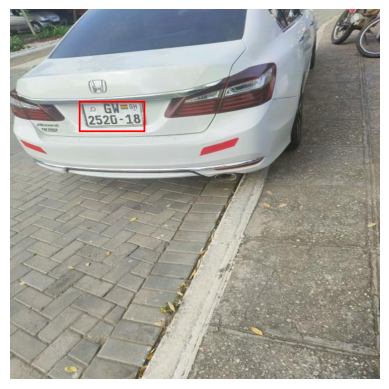

In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image, ImageDraw
import torch
import matplotlib.pyplot as plt

image_path = "image2.jpg"
image = Image.open(image_path)

# Initialize feature extractor and model (use YolosImageProcessor if your version supports it)
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities (softmax) and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the last class (background)
scores, labels = probs.max(-1)

# Filter predictions with a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()
# Draw the bounding boxes on the image
draw = ImageDraw.Draw(image)

for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = (x_center - width / 2) * image.width
    x_max = (x_center + width / 2) * image.width
    y_min = (y_center - height / 2) * image.height
    y_max = (y_center + height / 2) * image.height

    # Draw the bounding box
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)

# Convert the image to display via matplotlib
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.show()


# PARSING THE LICENSE DETECTION MODEL TO AN OCR MODEL TO EXTRACT TEXT

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 15.1 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/transformers/models/yolos/feature_extraction_yolos.py:38: FutureWarning: The class YolosFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use YolosImageProcessor instead.
  warnings.warn(


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

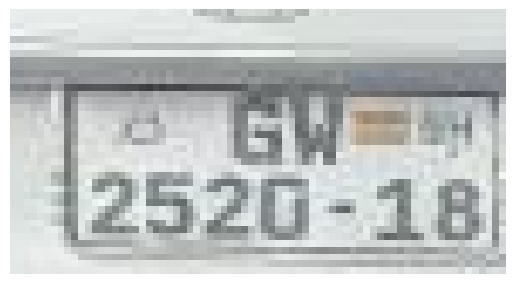

ValueError: Invalid input type. Supporting format = string(file path or url), bytes, numpy array

In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image, ImageDraw
import torch
import matplotlib.pyplot as plt
import easyocr

# Step 1: Load YOLOS model and detect license plates
image_path = "image.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use EasyOCR to extract text from the cropped license plates
reader = easyocr.Reader(['en'])  # Initialize EasyOCR reader for English

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Convert the PIL image to grayscale as required by EasyOCR
    plate_gray = plate.convert("L")

    # Use EasyOCR to read the license plate
    result = reader.readtext(plate_gray)

    # Display the recognized text
    if result:
        print(f"License Plate {i+1}: {result[0][-2]}")
    else:
        print(f"License Plate {i+1}: No text found")


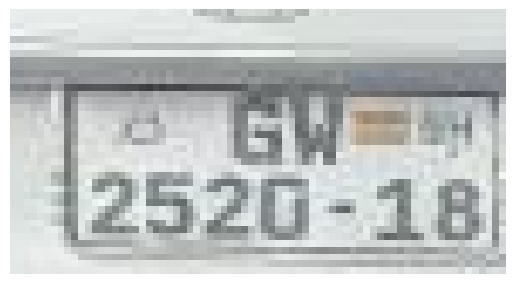

License Plate 1: 2520-18


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image, ImageDraw
import torch
import matplotlib.pyplot as plt
import easyocr
import numpy as np

# Step 1: Load YOLOS model and detect license plates
image_path = "image.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use EasyOCR to extract text from the cropped license plates
reader = easyocr.Reader(['en'])  # Initialize EasyOCR reader for English

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Convert the PIL image to a NumPy array
    plate_np = np.array(plate.convert("RGB"))

    # Use EasyOCR to read the license plate
    result = reader.readtext(plate_np)

    # Display the recognized text
    if result:
        print(f"License Plate {i+1}: {result[0][-2]}")
    else:
        print(f"License Plate {i+1}: No text found")


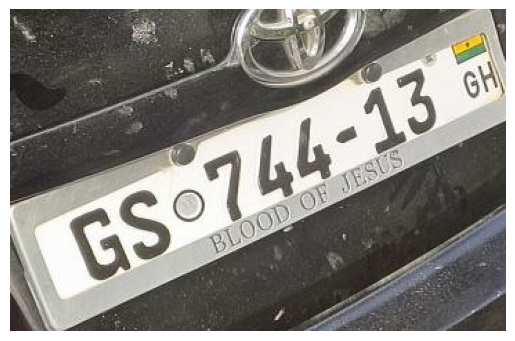

License Plate 1: GHi


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image, ImageDraw
import torch
import matplotlib.pyplot as plt
import easyocr
import numpy as np

# Step 1: Load YOLOS model and detect license plates
image_path = "image3.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use EasyOCR to extract text from the cropped license plates
reader = easyocr.Reader(['en'])  # Initialize EasyOCR reader for English

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Convert the PIL image to a NumPy array
    plate_np = np.array(plate.convert("RGB"))

    # Use EasyOCR to read the license plate
    result = reader.readtext(plate_np)

    # Display the recognized text
    if result:
        print(f"License Plate {i+1}: {result[0][-2]}")
    else:
        print(f"License Plate {i+1}: No text found")


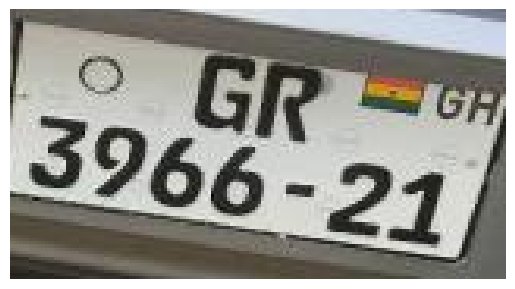

License Plate 1: GR


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image, ImageDraw
import torch
import matplotlib.pyplot as plt
import easyocr
import numpy as np

# Step 1: Load YOLOS model and detect license plates
image_path = "image4.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use EasyOCR to extract text from the cropped license plates
reader = easyocr.Reader(['en'])  # Initialize EasyOCR reader for English

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Convert the PIL image to a NumPy array
    plate_np = np.array(plate.convert("RGB"))

    # Use EasyOCR to read the license plate
    result = reader.readtext(plate_np)

    # Display the recognized text
    if result:
        print(f"License Plate {i+1}: {result[0][-2]}")
    else:
        print(f"License Plate {i+1}: No text found")


# USING THE FLAT_PLATE_OCR MODEL

In [ ]:
pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
pip install fast_plate_ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 MB 5.2 MB/s eta 0:00:00


preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/yolos/feature_extraction_yolos.py:38: FutureWarning: The class YolosFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use YolosImageProcessor instead.
  warnings.warn(
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/123M [00:00<?, ?B/s]

*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:490 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************


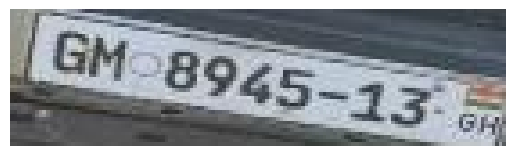

License Plate 1: ['AK845JJ']


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np
from fast_plate_ocr import ONNXPlateRecognizer

# Step 1: Load YOLOS model and detect license plates
image_path = "image4.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use ONNXPlateRecognizer to extract text from the cropped license plates
plate_recognizer = ONNXPlateRecognizer('argentinian-plates-cnn-model')

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Save the cropped plate as a temporary file for ONNX recognizer
    temp_plate_path = f"temp_plate_{i}.jpg"
    plate.save(temp_plate_path)

    # Use ONNXPlateRecognizer to read the license plate
    result = plate_recognizer.run(temp_plate_path)

    # Display the recognized text
    print(f"License Plate {i+1}: {result}")


In [ ]:
pip install TensorRT

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for TensorRT: filename=tensorrt-10.5.0-py2.py3-none-any.whl size=16338 sha256=09e3dd150fd97f0e6883422ee700a29adb5308d72aab29bb69ace61795dbfa50
  Stored in directory: /root/.cache/pip/wheels/17/93/2c/4db84c8fffd36bab9c54b39b4b886aaaaa1a1ab6d094d28a86
  Created wheel for tensorrt-cu12: filename=tensorrt_cu12-10.5.0-py2.py3-none-any.whl size=17555 sha256=ef609f8d98163cc566b205de939ccbab51976518bfdb33e46145ae7049074ec6
  Stored in directory: /root/.cache/pip/wheels/31/83/8a/84edbd0d600c1b334a5ac98e18626a458dc8a70d83d9c5ccbe
Successfully built TensorRT tensorrt-cu12


# FAST_PLATE_OCR MODEL

*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:490 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************


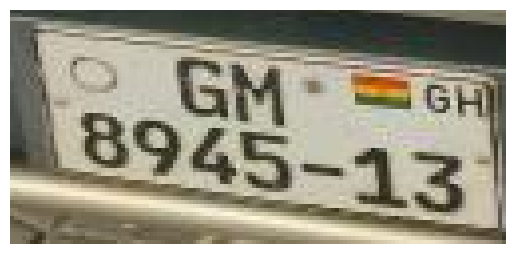

License Plate 1: ['GM894513_']


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np
from fast_plate_ocr import ONNXPlateRecognizer

# Step 1: Load YOLOS model and detect license plates
image_path = "image.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use ONNXPlateRecognizer to extract text from the cropped license plates
plate_recognizer = ONNXPlateRecognizer('european-plates-mobile-vit-v2-model')

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Save the cropped plate as a temporary file for ONNX recognizer
    temp_plate_path = f"temp_plate_{i}.jpg"
    plate.save(temp_plate_path)

    # Use ONNXPlateRecognizer to read the license plate
    result = plate_recognizer.run(temp_plate_path)

    # Display the recognized text
    print(f"License Plate {i+1}: {result}")


*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:490 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************


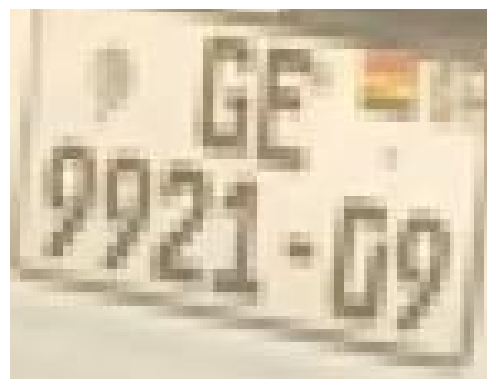

License Plate 1: ['GE992109_']


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np
from fast_plate_ocr import ONNXPlateRecognizer

# Step 1: Load YOLOS model and detect license plates
image_path = "image1.jpg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use ONNXPlateRecognizer to extract text from the cropped license plates
plate_recognizer = ONNXPlateRecognizer('european-plates-mobile-vit-v2-model')

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Save the cropped plate as a temporary file for ONNX recognizer
    temp_plate_path = f"temp_plate_{i}.jpg"
    plate.save(temp_plate_path)

    # Use ONNXPlateRecognizer to read the license plate
    result = plate_recognizer.run(temp_plate_path)

    # Display the recognized text
    print(f"License Plate {i+1}: {result}")


In [ ]:
from transformers import YolosFeatureExtractor, YolosForObjectDetection
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np
from fast_plate_ocr import ONNXPlateRecognizer

# Step 1: Load YOLOS model and detect license plates
image_path = "download.jpeg"
image = Image.open(image_path)

# Load YOLOS feature extractor and model
feature_extractor = YolosFeatureExtractor.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')
model = YolosForObjectDetection.from_pretrained('nickmuchi/yolos-small-finetuned-license-plate-detection')

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs)

# Extract logits and bounding boxes
logits = outputs.logits  # classification logits
bboxes = outputs.pred_boxes  # predicted bounding boxes

# Convert logits to probabilities and get predictions
probs = logits.softmax(-1)[0, :, :-1]  # Skip the background class
scores, labels = probs.max(-1)

# Set a confidence threshold
threshold = 0.5
high_confidence_indices = scores > threshold
predicted_boxes = bboxes[0, high_confidence_indices].detach().cpu().numpy()

# Step 2: Crop the detected license plates using bounding boxes
cropped_plates = []
for box in predicted_boxes:
    # YOLOS outputs boxes in [x_center, y_center, width, height], need to convert to [x_min, y_min, x_max, y_max]
    x_center, y_center, width, height = box
    x_min = int((x_center - width / 2) * image.width)
    x_max = int((x_center + width / 2) * image.width)
    y_min = int((y_center - height / 2) * image.height)
    y_max = int((y_center + height / 2) * image.height)

    # Crop the license plate from the image
    cropped_plate = image.crop((x_min, y_min, x_max, y_max))
    cropped_plates.append(cropped_plate)

# Step 3: Use ONNXPlateRecognizer to extract text from the cropped license plates
plate_recognizer = ONNXPlateRecognizer('european-plates-mobile-vit-v2-model')

# Process each cropped license plate and extract the text
for i, plate in enumerate(cropped_plates):
    plt.imshow(plate)
    plt.axis("off")
    plt.show()

    # Save the cropped plate as a temporary file for ONNX recognizer
    temp_plate_path = f"temp_plate_{i}.jpg"
    plate.save(temp_plate_path)

    # Use ONNXPlateRecognizer to read the license plate
    result = plate_recognizer.run(temp_plate_path)

    # Display the recognized text
    print(f"License Plate {i+1}: {result}")


/usr/local/lib/python3.10/dist-packages/transformers/models/yolos/feature_extraction_yolos.py:38: FutureWarning: The class YolosFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use YolosImageProcessor instead.
  warnings.warn(
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [ ]:
pip install fast_plate_ocr[train]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.9 MB/s eta 0:00:00


# SCRIPT FOR CLI TRAINING

In [ ]:
# Config example for ghana number plates config.yaml
# The old license plates contain 6 slots/characters (i.e. JUH697)
# and new 'Mercosur' contain 7 slots/characters (i.e. AB123CD)

# Max number of plate slots supported. This represents the number of model classification heads.
max_plate_slots: 10
# All the possible character set for the model output.
alphabet: '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ- '
# Padding character for plates which length is smaller than MAX_PLATE_SLOTS. It should still be present in the alphabet.
pad_char: ' '
# Image height which is fed to the model.
img_height: 70
# Image width which is fed to the model.
img_width: 140

In [ ]:
KERAS_BACKEND=tensorflow fast_plate_ocr train \
    --annotations '/Users/ninte/desktop/fast-plate-ocr/ghanaocr/Ghanaian License Plates.v2i.tensorflow/train/annotations.csv' \
    --val-annotations '/Users/ninte/desktop/fast-plate-ocr/ghanaocr/Ghanaian License Plates.v2i.tensorflow/valid/annotations.csv' \
    --config-file '/Users/ninte/desktop/fast-plate-ocr/ghanaocr/config.yaml' \
    --batch-size 128 \
    --epochs 750 \
    --dense \
    --early-stopping-patience 100 \
    --reduce-lr-patience 50 > training_log.txt


# DOCUMENT OCR MODEL

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 16.8 MB/s eta 0:00:00


In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 3.9 MB/s eta 0:00:00


In [ ]:

!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 42.2 MB/s eta 0:00:00


In [ ]:

from google.colab import files
import easyocr
import fitz  # PyMuPDF for PDFs
from docx import Document
from PIL import Image
import io
import numpy as np

# Initialize EasyOCR reader (specify languages as needed, e.g., 'en' for English)
reader = easyocr.Reader(['en'])

# Function to extract text from an image
def extract_text_from_image(image_file):
    image = Image.open(image_file)
    image = image.convert('RGB')
    image_np = np.array(image)  # Convert the image to a NumPy array
    result = reader.readtext(image_np, detail=0)
    return ' '.join(result)

# Function to extract text from a PDF
def extract_text_from_pdf(pdf_file):
    text = ''
    pdf = fitz.open(pdf_file)
    for page_num in range(len(pdf)):
        page = pdf.load_page(page_num)
        text += page.get_text()
    return text

# Function to extract text from a DOCX file
def extract_text_from_docx(docx_file):
    doc = Document(docx_file)
    text = [para.text for para in doc.paragraphs]
    return '\n'.join(text)

# Upload the file
uploaded = files.upload()

# Iterate through uploaded files
for file_name in uploaded.keys():
    if file_name.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        print(f"Extracting text from image: {file_name}")
        text = extract_text_from_image(io.BytesIO(uploaded[file_name]))
        print("Extracted Text:\n", text)

    elif file_name.endswith('.pdf'):
        print(f"Extracting text from PDF: {file_name}")
        text = extract_text_from_pdf(io.BytesIO(uploaded[file_name]))
        print("Extracted Text:\n", text)

    elif file_name.endswith('.docx'):
        print(f"Extracting text from DOCX: {file_name}")
        text = extract_text_from_docx(io.BytesIO(uploaded[file_name]))
        print("Extracted Text:\n", text)

    else:
        print(f"Unsupported file type: {file_name}")


Saving 2017-07-31-15-24-45-medical-images-compression-jpeg-variations-for-dicom-standard-2-728.jpg to 2017-07-31-15-24-45-medical-images-compression-jpeg-variations-for-dicom-standard-2-728.jpg
Extracting text from image: 2017-07-31-15-24-45-medical-images-compression-jpeg-variations-for-dicom-standard-2-728.jpg
Extracted Text:
 image quality  Stated another way; the of this processing step is to discard information which not visually signiticant: The outcome of quantizing the DCT coefficients is that smaller; unimportant coefficients will disappear and larger coefficients will lose unnecessary precision The final  step in JPEG compression is called Coding' which involves three sub-processes: DC Coding_ Zig-Zag Sequence and Entropy Coding_ The DC" coefficient in the matrix_ which is the top eft-most value contains higher integer that measure f the average value of the 64 image samples. DC coding replaces every blocks DC coefficient with the difference between it and the Une of the prev

In [ ]:

from google.colab import files
import easyocr
import fitz  # PyMuPDF for PDFs
from docx import Document
from PIL import Image
import io
import numpy as np

# Initialize EasyOCR reader (specify languages as needed, e.g., 'en' for English)
reader = easyocr.Reader(['en'])

# Function to extract text from an image
def extract_text_from_image(image_file):
    image = Image.open(image_file)
    image = image.convert('RGB')
    image_np = np.array(image)  # Convert the image to a NumPy array
    result = reader.readtext(image_np, detail=0)
    return ' '.join(result)

# Function to extract text from a PDF
def extract_text_from_pdf(pdf_file):
    text = ''
    # Open PDF from byte stream
    pdf = fitz.open(stream=pdf_file, filetype="pdf")
    for page_num in range(len(pdf)):
        page = pdf.load_page(page_num)
        text += page.get_text()
    return text

# Function to extract text from a DOCX file
def extract_text_from_docx(docx_file):
    doc = Document(docx_file)
    text = [para.text for para in doc.paragraphs]
    return '\n'.join(text)

# Upload the file
uploaded = files.upload()

# Iterate through uploaded files
for file_name in uploaded.keys():
    if file_name.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        print(f"Extracting text from image: {file_name}")
        text = extract_text_from_image(io.BytesIO(uploaded[file_name]))
        print("Extracted Text:\n", text)

    elif file_name.endswith('.pdf'):
        print(f"Extracting text from PDF: {file_name}")
        text = extract_text_from_pdf(io.BytesIO(uploaded[file_name]))
        print("Extracted Text:\n", text)

    elif file_name.endswith('.docx'):
        print(f"Extracting text from DOCX: {file_name}")
        text = extract_text_from_docx(io.BytesIO(uploaded[file_name]))
        print("Extracted Text:\n", text)

    else:
        print(f"Unsupported file type: {file_name}")


Saving 2019-06-03-12-39-36-EST-NLA-GM 3412-12.pdf to 2019-06-03-12-39-36-EST-NLA-GM 3412-12.pdf
Extracting text from PDF: 2019-06-03-12-39-36-EST-NLA-GM 3412-12.pdf
Extracted Text:
 


# OCR MODEL FOR IMAGES AND DOCX CONTAINING WITH TABLES AND FIGURES

In [ ]:
!pip install pytesseract

In [ ]:
!apt install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 3s (1,539 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 123622 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

In [ ]:
!pip install pillow

In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 4.1 MB/s eta 0:00:00


In [ ]:
!pip install opencv-python

In [ ]:
!pip install fitz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.5/421.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.1/528.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.0 MB/s eta 0:00:00
  Created wheel for configobj: filename=configobj-5.0.9-py2.py3-none-any.whl size=35615 sha256=72b8e109ee5ecb655f4f5b862e95a7cad371e151baae41ecacab99a4678e65aa
  Stored in directory: /root/.cache/pip/wheels/a1/6c/03/6c5e3cf1a6e4b9

In [ ]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 35.8 MB/s eta 0:00:00


In [ ]:
!pip install docquery

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 20.6 MB/s eta 0:00:00


In [ ]:
!pip install docquery

In [ ]:
pip install pydantic==1.10.12


In [ ]:
pip install --upgrade docquery


In [ ]:
!apt-get install -y poppler-utils
!pip install docquery pdf2image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 186 kB of archives.
After this operation, 696 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.5 [186 kB]
Fetched 186 kB in 1s (150 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 123669 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.5_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.5) ...
Setting up poppler-utils (22.02.0-2ubuntu0.5) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
from docquery import document, pipeline

def query_document(doc_path, questions):
    """
    Queries the PDF or image document using DocQuery for specific questions.

    Parameters:
    - doc_path: Path to the document (PDF or image).
    - questions: A list of questions to query the document.

    Returns:
    - answers: A dictionary containing questions as keys and answers as values.
    """
    # Load document and pipeline
    doc = document.load_document(doc_path)
    qa_pipeline = pipeline('document-question-answering')

    # Query the document with the provided questions
    answers = {}
    for question in questions:
        # Get the answer and retrieve the text field from the output
        result = qa_pipeline(question=question, **doc.context)
        answer_text = result.get("answer", "No answer found")
        answers[question] = answer_text
        print(f"Question: {question}\nAnswer: {answer_text}")

    return answers

# Example usage
if __name__ == "__main__":
    # Upload the PDF in Colab and specify the path
    from google.colab import files
    uploaded = files.upload()
    document_path = list(uploaded.keys())[0]  # Get the uploaded file's path

    questions_to_ask = [
        "What is the invoice number?",
        "What is the invoice total?",
        "What is the effective date?"
    ]

    # Query the document
    query_document(document_path, questions_to_ask)


Saving 2018-08-01-16-06-27-scan (8).pdf to 2018-08-01-16-06-27-scan (8).pdf


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Exception: You cannot use ``pop`` on a ModelOutput instance.

In [ ]:
from docquery import document, pipeline
p = pipeline('document-question-answering')
doc = document.load_document("1.pdf")
for q in ["What is the invoice number?", "What is the invoice total?"]:
  print(q, p(question=q, **doc.context))


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Exception: You cannot use ``pop`` on a ModelOutput instance.

# LICENSE PLATE OCR

# TRANSFER LEARNING WITH  MOBILENENT AND BUILDING THE RNN AND LSTM MODELS FOR THE OCR OUPUT CLASS

In [ ]:
  # List the contents of 'MyDrive' to locate the correct folder
!ls /content/drive/MyDrive/


 -5785384170086842277_121_jpg.rf.b903f05ef8ea9222014daa2e5d1ab2e3.jpg
'Colab Notebooks'
'Ghanaian License Plates.v2i.tfrecord'


# Labelled data on car Ghanaian number plates saved in tensorflow csv form

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
  # List the contents of 'MyDrive' to locate the correct folder
!ls /content/drive/MyDrive/


 -5785384170086842277_121_jpg.rf.b903f05ef8ea9222014daa2e5d1ab2e3.jpg   test
'Colab Notebooks'						        train
'Ghanaian License Plates.v2i.tfrecord'				        valid


In [ ]:
import pandas as pd
from pathlib import Path

# Define paths to the datasets
train_csv = '/content/drive/MyDrive/train/annotations.csv'
valid_csv = '/content/drive/MyDrive/valid/_annotations.csv'
test_csv = '/content/drive/MyDrive/test/_annotations.csv'

# Function to clean dataset
def clean_dataset(csv_file):
    # Load the dataset
    df = pd.read_csv(csv_file)

    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Drop duplicates based on 'filename' and keep the first occurrence
    df = df.drop_duplicates(subset='filename')

    # Get the list of image filenames in the respective directories
    img_dir = Path(csv_file).parent
    existing_images = set(img.name for img in img_dir.glob("*.*") if img.suffix.lower() in ['.jpg', '.jpeg', '.png'])

    # Remove entries where the corresponding image does not exist
    df = df[df['filename'].isin(existing_images)]

    # Save the cleaned dataset back to CSV
    cleaned_csv_file = csv_file.replace('.csv', '_cleaned.csv')
    df.to_csv(cleaned_csv_file, index=False)
    print(f"Cleaned dataset saved to: {cleaned_csv_file}")
    print(f"Number of entries after cleaning: {len(df)}")

    return df

# Clean the datasets
train_cleaned = clean_dataset(train_csv)
valid_cleaned = clean_dataset(valid_csv)
test_cleaned = clean_dataset(test_csv)


Cleaned dataset saved to: /content/drive/MyDrive/train/annotations_cleaned.csv
Number of entries after cleaning: 223
Cleaned dataset saved to: /content/drive/MyDrive/valid/_annotations_cleaned.csv
Number of entries after cleaning: 66
Cleaned dataset saved to: /content/drive/MyDrive/test/_annotations_cleaned.csv
Number of entries after cleaning: 32


In [ ]:
import pandas as pd
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Paths to your CSV files
train_csv = '/content/drive/MyDrive/train/annotations_cleaned.csv'
valid_csv = '/content/drive/MyDrive/valid/_annotations_cleaned.csv'
test_csv = '/content/drive/MyDrive/test/_annotations_cleaned.csv'  # Add this line for the test CSV

# Function to rename columns in a CSV file and save the updated file
def rename_columns_and_download(csv_path):
    # Read the CSV file
    df = pd.read_csv(csv_path)
    # Rename the columns
    df.rename(columns={'license_plate': 'plate_text', 'filename': 'image_path'}, inplace=True)

    # Filter to keep only the desired columns
    df_filtered = df[['image_path', 'plate_text']]

    # Save the modified CSV file back to a temporary location
    updated_csv_path = csv_path.replace('.csv', '_updated.csv')
    df_filtered.to_csv(updated_csv_path, index=False)

    # Download the updated file
    files.download(updated_csv_path)

# Rename columns and download updated files
rename_columns_and_download(train_csv)
rename_columns_and_download(valid_csv)
rename_columns_and_download(test_csv)  # Update for the test CSV


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import cv2

# Define paths to the datasets
train_csv = '/content/drive/MyDrive/train/annotations_cleaned.csv'
valid_csv = '/content/drive/MyDrive/valid/_annotations_cleaned.csv'
test_csv = '/content/drive/MyDrive/test/_annotations_cleaned.csv'

# Define characters used for encoding labels
characters = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ- "
max_length = 10  # Maximum length of license plate strings

# Function to log invalid characters
def log_invalid_characters(labels):
    all_characters = set()
    for label in labels:
        all_characters.update(set(label))  # Add all unique characters from each label
    invalid_characters = [char for char in all_characters if char not in characters]
    if invalid_characters:
        print(f"Invalid characters found in labels: {set(invalid_characters)}")


In [ ]:
class LicensePlateDataset(tf.keras.utils.Sequence):
    def __init__(self, csv_file, img_dir, batch_size=32, img_size=(224, 224), shuffle=True):
        self.csv_file = pd.read_csv(csv_file)
        self.csv_file.columns = self.csv_file.columns.str.strip()  # Strip whitespace from headers
        print("Columns in CSV:", self.csv_file.columns.tolist())  # Print column names
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()
        log_invalid_characters(self.csv_file['license_plate'].values)  # Check for invalid characters

    def __len__(self):
        return int(np.floor(len(self.csv_file) / self.batch_size))

    def __getitem__(self, index):
        batch_data = self.csv_file.iloc[index * self.batch_size:(index + 1) * self.batch_size]
        images = []
        labels = []

        for _, row in batch_data.iterrows():
            img_path = Path(self.img_dir) / row['filename']
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)  # Read grayscale
            img = cv2.resize(img, self.img_size)  # Resize to 224x224

            # Convert grayscale images to RGB by stacking grayscale into 3 channels
            img = np.stack((img,) * 3, axis=-1)  # Convert to RGB by stacking grayscale into 3 channels
            img = img / 255.0  # Normalize
            img = img.astype('float32')  # Convert to float32

            images.append(img)
            labels.append(row['license_plate'])  # Use 'license_plate' for labels

        images = np.array(images)
        labels = self.encode_labels(labels)
        return images, labels

    def encode_labels(self, labels):
        encoded = []
        for label in labels:
            try:
                encoded_label = [characters.index(char) for char in label]
                # Apply truncation or padding to match max_length
                if len(encoded_label) > max_length:
                    encoded_label = encoded_label[:max_length]  # Truncate
                else:
                    encoded_label += [len(characters)] * (max_length - len(encoded_label))  # Pad
                encoded.append(encoded_label)
            except ValueError as e:
                print(f"Error encoding label '{label}': {e}")  # Log the error for invalid labels
                encoded.append([len(characters)] * max_length)  # Append padding if there's an error
        return np.array(encoded)

    def on_epoch_end(self):
        if self.shuffle:
            self.csv_file = self.csv_file.sample(frac=1).reset_index(drop=True)


In [ ]:

# Create the datasets
train_dataset = LicensePlateDataset(train_csv, '/content/drive/MyDrive/train')
valid_dataset = LicensePlateDataset(valid_csv, '/content/drive/MyDrive/valid')

# Check for duplicates and missing images
train_annotations = pd.read_csv(train_csv)
valid_annotations = pd.read_csv(valid_csv)

# Check number of unique images
print("Unique entries in train annotations:", train_annotations['filename'].nunique())
print("Unique entries in valid annotations:", valid_annotations['filename'].nunique())

# Check if there are any missing images in the training dataset
train_images = sorted(list(Path('/content/drive/MyDrive/train').glob('*.jpg')))  # or other formats
train_images = [img.name for img in train_images]

missing_train_images = [file for file in train_annotations['filename'] if file not in train_images]
print("Missing images in train dataset:", missing_train_images)

# Define CTC Loss Function
def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)

# Model Building
def build_ocr_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape, name='image_input')

    # Use MobileNetV2 with pre-trained weights
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(input_shape[0], input_shape[1], 3))  # (224, 224, 3) for RGB

    for layer in base_model.layers:
        layer.trainable = False  # Freeze all layers

    # Custom CNN-RNN layers for OCR
    x = base_model.output
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.Reshape(target_shape=(-1, x.shape[-1]))(x)  # Flatten for LSTM

    # Add RNN layers (Bidirectional LSTM)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # Dense layer to output probabilities for each character
    output = layers.Dense(num_classes + 1, activation='softmax', name='output')(x)

    return Model(inputs, output)

# Model Training
input_shape = (224, 224, 3)  # Height, width, 3 channels for RGB images
num_classes = len(characters)  # Number of unique characters

ocr_model = build_ocr_model(input_shape, num_classes)
ocr_model.compile(optimizer=Adam(), loss=ctc_lambda_func)

# Callbacks for saving and early stopping
callbacks = [
    ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1)
]

# Train the model
history = ocr_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=50,
    callbacks=callbacks
)


Columns in CSV: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax', 'license_plate']
Columns in CSV: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax', 'license_plate']
Unique entries in train annotations: 223
Unique entries in valid annotations: 66
Missing images in train dataset: []
Epoch 1/50


KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m137293950475936\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)\n  • training=True\n  • mask=None'

In [ ]:
!pip install fast_plate_ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
from fast_plate_ocr import ONNXPlateRecognizer

m = ONNXPlateRecognizer('argentinian-plates-cnn-model')
print(m.run('image.jpg'))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import cv2
import pandas as pd
from pathlib import Path

# Define constants
characters = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ- "
max_length = 10
img_width = 224
img_height = 224

class LicensePlateDataset(tf.keras.utils.Sequence):
    def __init__(self, csv_file, img_dir, batch_size=32, img_size=(224, 224), shuffle=True):
        self.csv_file = pd.read_csv(csv_file)
        self.csv_file.columns = self.csv_file.columns.str.strip()
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.csv_file))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.csv_file) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = self.csv_file.iloc[batch_indices]

        # Initialize arrays
        images = np.zeros((self.batch_size, *self.img_size, 3), dtype=np.float32)
        labels = np.zeros((self.batch_size, max_length), dtype=np.int32)

        # Calculate input_length based on the network architecture
        feature_length = self.img_size[1] // 32
        input_length = np.ones((self.batch_size, 1), dtype=np.int32) * feature_length
        label_length = np.zeros((self.batch_size, 1), dtype=np.int32)

        for i, (_, row) in enumerate(batch_data.iterrows()):
            # Process image
            img_path = Path(self.img_dir) / row['filename']
            img = cv2.imread(str(img_path))
            if img is None:
                raise ValueError(f"Could not read image: {img_path}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            images[i] = img

            # Process label
            label = str(row['license_plate']).strip()
            label_length[i] = len(label)
            encoded_label = self.encode_label(label)
            labels[i] = encoded_label

        inputs = {
            'input_img': images,
            'labels': labels,
            'input_length': input_length,
            'label_length': label_length
        }

        # Use dummy outputs for CTC loss
        outputs = {'ctc': np.zeros((self.batch_size, 1))}

        return inputs, outputs

    def encode_label(self, label):
        encoded = np.zeros(max_length, dtype=np.int32)
        for i, char in enumerate(label[:max_length]):
            if char in characters:
                encoded[i] = characters.index(char)
        return encoded

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

def ctc_lambda_func(args):
    labels, y_pred, input_length, label_length = args
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)

def build_ocr_model(input_shape, num_classes):
    # Input layers
    input_img = tf.keras.Input(shape=input_shape, name='input_img')
    labels = tf.keras.Input(name='labels', shape=(None,), dtype='int32')
    input_length = tf.keras.Input(name='input_length', shape=(1,), dtype='int32')
    label_length = tf.keras.Input(name='label_length', shape=(1,), dtype='int32')

    # Base model - MobileNetV2
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_tensor=input_img,
        input_shape=input_shape
    )

    # Freeze early layers
    for layer in base_model.layers[:100]:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)

    # Prepare for sequence processing
    _, h, w, c = x.shape
    x = layers.Reshape((-1, h * c), name='reshape_1')(x)

    # RNN layers
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, name='lstm_1'))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, name='lstm_2'))(x)
    x = layers.Dropout(0.25)(x)

    # Output layer
    outputs = layers.Dense(num_classes + 1, activation='softmax', name='dense_output')(x)

    # Define CTC loss
    loss_out = layers.Lambda(ctc_lambda_func, output_shape=(1,), name='ctc')(
        [labels, outputs, input_length, label_length]
    )

    # Create training model
    train_model = Model(
        inputs=[input_img, labels, input_length, label_length],
        outputs=loss_out
    )

    # Create prediction model
    pred_model = Model(input_img, outputs)

    return train_model, pred_model

def create_callbacks(model_path='best_model.keras'):
    return [
        ModelCheckpoint(
            model_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            verbose=1,
            restore_best_weights=True
        )
    ]

# Create and compile the model
input_shape = (img_height, img_width, 3)
num_classes = len(characters)

train_model, pred_model = build_ocr_model(input_shape, num_classes)

# Custom optimizer with gradient clipping
optimizer = Adam(learning_rate=0.001, clipnorm=5)

train_model.compile(
    optimizer=optimizer,
    loss={'ctc': lambda y_true, y_pred: y_pred},
    run_eagerly=True
)

# Create datasets
train_dataset = LicensePlateDataset(train_csv, '/content/drive/MyDrive/train', batch_size=16)
valid_dataset = LicensePlateDataset(valid_csv, '/content/drive/MyDrive/valid', batch_size=16)

# Train the model
history = train_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=50,
    callbacks=create_callbacks(),
    verbose=1
)

# Prediction function
def decode_predictions(pred_model, image_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_width, img_height))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = pred_model.predict(img)

    # Get the most likely character at each position
    pred_text = []
    for p in pred[0]:
        char_idx = np.argmax(p)
        if char_idx < len(characters):  # Ignore CTC blank character
            pred_text.append(characters[char_idx])

    return ''.join(pred_text)

# Function to evaluate model performance
def evaluate_model(pred_model, test_dataset):
    correct = 0
    total = 0

    for inputs, _ in test_dataset:
        images = inputs['input_img']
        true_labels = inputs['labels']

        for i in range(len(images)):
            pred = pred_model.predict(np.expand_dims(images[i], axis=0))
            pred_text = decode_predictions(pred_model, pred)
            true_text = ''.join([characters[idx] for idx in true_labels[i] if idx < len(characters)])

            if pred_text == true_text:
                correct += 1
            total += 1

    accuracy = correct / total
    print(f"Model Accuracy: {accuracy:.2%}")
    return accuracy

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


InvalidArgumentError: Exception encountered when calling Lambda.call().

[1m{{function_node __wrapped__Squeeze_device_/job:localhost/replica:0/task:0/device:CPU:0}} Can not squeeze dim[1], expected a dimension of 1, got 10 [Op:Squeeze] name: [0m

Arguments received by Lambda.call():
  • inputs=['tf.Tensor(shape=(16, 1), dtype=int32)', 'tf.Tensor(shape=(16, 7, 39), dtype=float32)', 'tf.Tensor(shape=(16, 1), dtype=int32)', 'tf.Tensor(shape=(16, 10), dtype=int32)']
  • mask=['None', 'None', 'None', 'None']
  • training=True

In [ ]:
history = train_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=50,
    callbacks=create_callbacks(),
    verbose=1
)

Epoch 1/50


InvalidArgumentError: Exception encountered when calling Lambda.call().

[1m{{function_node __wrapped__Squeeze_device_/job:localhost/replica:0/task:0/device:CPU:0}} Can not squeeze dim[1], expected a dimension of 1, got 10 [Op:Squeeze] name: [0m

Arguments received by Lambda.call():
  • inputs=['tf.Tensor(shape=(16, 1), dtype=int32)', 'tf.Tensor(shape=(16, 7, 39), dtype=float32)', 'tf.Tensor(shape=(16, 1), dtype=int32)', 'tf.Tensor(shape=(16, 10), dtype=int32)']
  • mask=['None', 'None', 'None', 'None']
  • training=True

In [ ]:
accuracy = evaluate_model(pred_model, valid_dataset)

In [ ]:
prediction = decode_predictions(pred_model, "path_to_image.jpg")

In [ ]:

# Save the final model
ocr_model.save('final_model.keras')


# FINETUNING THE KEARS-OCR MODEL

In [ ]:
!pip install keras-ocr tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.5 MB/s eta 0:00:00


In [ ]:
import keras_ocr
import pandas as pd
import os
import tensorflow as tf

# Function to load dataset from CSV
def load_dataset(csv_path, base_img_dir):
    df = pd.read_csv(csv_path)
    images = []
    labels = []

    for idx, row in df.iterrows():
        img_path = os.path.join(base_img_dir, row['filename'])
        label = row['license_plate']
        images.append(img_path)
        labels.append(label)

    return images, labels

# Load datasets
train_csv = '/content/drive/MyDrive/train/annotations_cleaned.csv'
valid_csv = '/content/drive/MyDrive/valid/_annotations_cleaned.csv'
test_csv = '/content/drive/MyDrive/test/_annotations_cleaned.csv'

train_images, train_labels = load_dataset(train_csv, '/content/drive/MyDrive/train/')
valid_images, valid_labels = load_dataset(valid_csv, '/content/drive/MyDrive/valid/')
test_images, test_labels = load_dataset(test_csv, '/content/drive/MyDrive/test/')


In [ ]:
# Initialize the Keras-OCR pipeline
pipeline = keras_ocr.pipeline.Pipeline()

# Use the pre-trained detection and recognition models
detector = pipeline.detector
recognizer = pipeline.recognizer

# Optionally fine-tune recognizer (transfer learning)
base_model = recognizer.model
base_model.trainable = True  # Enable training for all layers

# Define custom training loop (you can use TensorFlow’s fit method)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
base_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Convert training and validation data into format suitable for Keras-OCR
train_data = [(img, label) for img, label in zip(train_images, train_labels)]
valid_data = [(img, label) for img, label in zip(valid_images, valid_labels)]

# You can now fit the recognizer model
base_model.fit(
    train_data,  # replace with a proper generator if needed
    validation_data=valid_data,
    epochs=10,  # Adjust based on your dataset size
    batch_size=16
)


Looking for /root/.keras-ocr/craft_mlt_25k.h5


ValueError: Unrecognized keyword arguments passed to Dense: {'weights': [array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
   

In [ ]:
# Evaluate the model on test data
test_data = [(img, label) for img, label in zip(test_images, test_labels)]
loss, accuracy = base_model.evaluate(test_data)

print(f"Test Accuracy: {accuracy * 100:.2f}%")


In [ ]:
base_model.save('/content/drive/MyDrive/fine_tuned_keras_ocr_model.h5')
